<a href="https://colab.research.google.com/github/nkefeyan-22-26/IV-Analysis-Replication/blob/main/MidtermProject/data/raw/notebooks/03_Extention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nathan Kefeyan
# ECON5200 Midterm Project
# Instrumental Variables Recreation - Angrist & Evans 1998 Recreation
# Phase 3: Extension Analysis


In [1]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt

In [4]:
FILEPATH = '/content/census80_slim.csv.gz'
df_slim = pd.read_csv(FILEPATH)
df_slim.columns = df_slim.columns.str.lower()

def decode_col(col):
    if col.dtype == object:
        col = col.str.lstrip("b'").str.rstrip("'")
    return pd.to_numeric(col, errors='coerce')

df_slim = df_slim.apply(decode_col)

df_slim['samesex'] = (df_slim['sexk'] == df_slim['sex2nd']).astype(int)
df_slim['morekids'] = (df_slim['kidcount'] > 2).astype(int)

cols = ['morekids', 'samesex', 'agem', 'gradem', 'racem', 'weeksm']
df_slim_clean = df_slim[cols].replace([np.inf, -np.inf], np.nan).dropna()

df_slim['racem'] = df_slim['racem'].replace({3: 12, 4: 12, 5: 12, 6: 12})

# AI Expansion
1980 Census Race Codes map to the following:
1 = White
2 = Black
3 = American Indian
4 = Chinese
5 = Japanese
6 = Other Asian
12 = Other race

# Pitch
I can split the sample by race and run separate 2SLS models to see if the labor supply penalty of having more kids differs by race. With the current visualization, we can see that white mothers whose family size was driven by same-sex sibling preference, having a third child reduces weeks worked by ~7 weeks more than black mothers. Other groups face slightly smaller penalties. All of the effects are negative, so this is statistically significant across all groups.

Trying to find an explanation: One possible explanation is that White mothers in 1980 had a strong tendancy to leave the workforce entirely after their third child, while Black and other minority mothers had higher LFPRs due to economic necessity, making them less able to reduce their work hours even after having additional children.

In [5]:
race_groups = {
    'White': 1,
    'Black': 2,
    'Other': 12
}

results = []

for race_name, race_code in race_groups.items():
    # Subset
    df_race = df_slim_clean[df_slim_clean['racem'] == race_code].copy()
    df_race = df_race[['weeksm', 'morekids', 'samesex', 'agem', 'gradem']].replace([np.inf, -np.inf], np.nan).dropna()

    # IV2SLS
    iv = IV2SLS(
        dependent   = df_race['weeksm'],
        exog        = sm.add_constant(df_race[['agem', 'gradem']]),
        endog       = df_race['morekids'],
        instruments = df_race['samesex']
    ).fit(cov_type='robust')

    coef = iv.params['morekids']
    se   = iv.std_errors['morekids']
    ci_low  = iv.conf_int().loc['morekids', 'lower']
    ci_high = iv.conf_int().loc['morekids', 'upper']
    n    = len(df_race)

    results.append({
        'Race':   race_name,
        'N':      n,
        'Coef':   round(coef, 4),
        'SE':     round(se, 4),
        'CI Low':  round(ci_low, 4),
        'CI High': round(ci_high, 4)
    })

    print(f"\n=== {race_name} (n={n:,}) ===")
    print(iv.summary)

# Summary table
results_df = pd.DataFrame(results)
print("\n=== Summary: Effect of morekids on weeksm by Race ===")
print(results_df.to_string(index=False))


=== White (n=764,068) ===
                          IV-2SLS Estimation Summary                          
Dep. Variable:                 weeksm   R-squared:                     -0.0117
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0117
No. Observations:              764068   F-statistic:                 1.504e+04
Date:                Tue, Mar 31 2026   P-value (F-stat)                0.0000
Time:                        18:06:54   Distribution:                  chi2(3)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          5.5599     0.1934     28.755     0.0000      5.1809      5.9388
agem           0.5287    

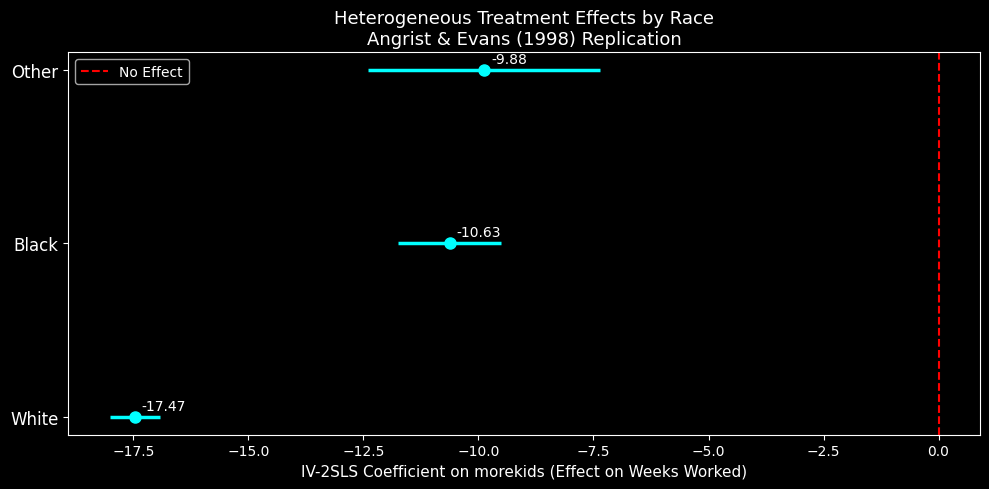

In [7]:
# Forest Plot - Mothers by Race

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in results_df.iterrows():
    ax.plot(row['Coef'], i, 'o', color='cyan', markersize=8, zorder=3)
    ax.hlines(i, row['CI Low'], row['CI High'], color='cyan', linewidth=2.5)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='No Effect')

ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Race'], fontsize=12)
ax.set_xlabel('IV-2SLS Coefficient on morekids (Effect on Weeks Worked)', fontsize=11)
ax.set_title('Heterogeneous Treatment Effects by Race\nAngrist & Evans (1998) Replication', fontsize=13)

for i, row in results_df.iterrows():
    ax.annotate(f"{row['Coef']:.2f}", xy=(row['Coef'], i),
                xytext=(5, 5), textcoords='offset points',
                color='white', fontsize=10)

ax.legend()
plt.tight_layout()
# plt.savefig('../data/raw/notebooks/forest_plot_race.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(df_slim[['hoursd', 'income1d', 'weeksd']].describe())

              hoursd       income1d         weeksd
count  762843.000000  762843.000000  762843.000000
mean       42.905771   16818.576214      47.399563
std        12.586895   11964.223274      11.307519
min         0.000000       0.000000       0.000000
25%        40.000000    9765.000000      50.000000
50%        40.000000   16005.000000      52.000000
75%        48.000000   22105.000000      52.000000
max        99.000000   75000.000000      52.000000


In [9]:
# CELL - Father subgroup IV models by race
race_groups = {
    'White': 1,
    'Black': 2,
    'Other': 12
}

results_dad = []

for race_name, race_code in race_groups.items():
    df_race = df_slim[df_slim['racem'] == race_code].copy()
    df_race = df_race[['weeksd', 'morekids', 'samesex', 'agem', 'gradem']].replace([np.inf, -np.inf], np.nan).dropna()

    iv = IV2SLS(
        dependent   = df_race['weeksd'],
        exog        = sm.add_constant(df_race[['agem', 'gradem']]),
        endog       = df_race['morekids'],
        instruments = df_race['samesex']
    ).fit(cov_type='robust')

    results_dad.append({
        'Race':    race_name,
        'Coef':    round(iv.params['morekids'], 4),
        'CI Low':  round(iv.conf_int().loc['morekids', 'lower'], 4),
        'CI High': round(iv.conf_int().loc['morekids', 'upper'], 4)
    })

results_dad_df = pd.DataFrame(results_dad)
print(results_dad_df)

    Race    Coef  CI Low  CI High
0  White  2.0728  1.7966   2.3490
1  Black  2.0511  0.8758   3.2263
2  Other  1.1891 -0.3431   2.7213


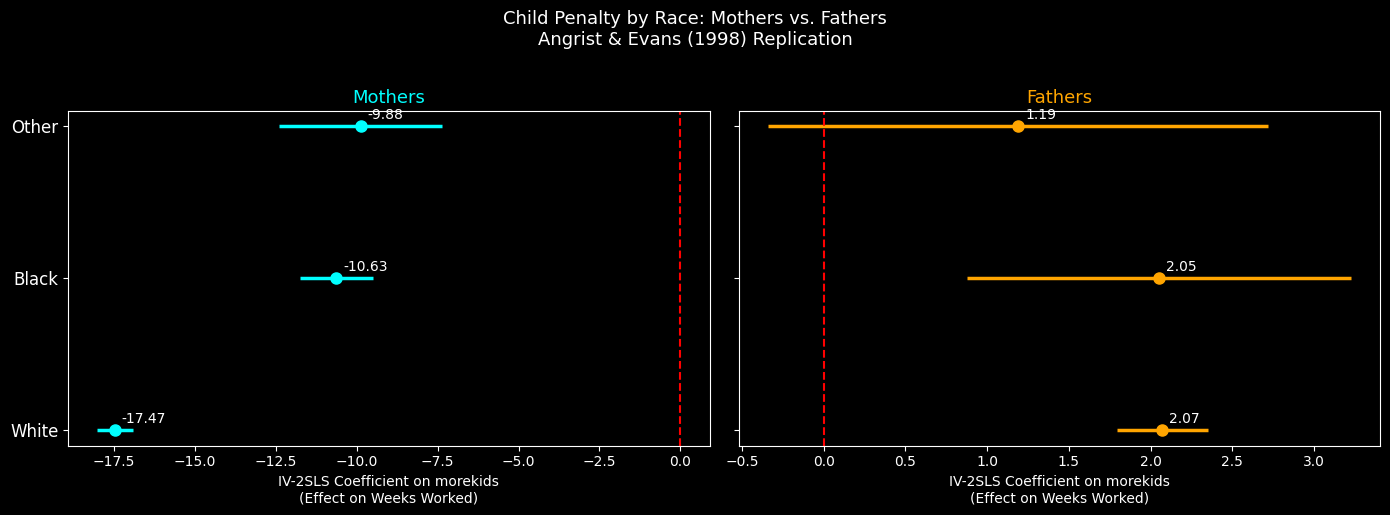

In [10]:
# CELL - Side by side forest plot: mothers vs fathers
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, res_df, title, color in zip(
    axes,
    [results_df, results_dad_df],
    ['Mothers', 'Fathers'],
    ['cyan', 'orange']
):
    for i, row in res_df.iterrows():
        ax.plot(row['Coef'], i, 'o', color=color, markersize=8, zorder=3)
        ax.hlines(i, row['CI Low'], row['CI High'], color=color, linewidth=2.5)
        ax.annotate(f"{row['Coef']:.2f}", xy=(row['Coef'], i),
                    xytext=(5, 5), textcoords='offset points',
                    color='white', fontsize=10)

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_yticks(range(len(res_df)))
    ax.set_yticklabels(res_df['Race'], fontsize=12)
    ax.set_xlabel('IV-2SLS Coefficient on morekids\n(Effect on Weeks Worked)', fontsize=10)
    ax.set_title(title, fontsize=13, color=color)

fig.suptitle('Child Penalty by Race: Mothers vs. Fathers\nAngrist & Evans (1998) Replication',
             fontsize=13, y=1.02)

plt.tight_layout()
# plt.savefig('../data/raw/notebooks/forest_plot_mothers_vs_fathers.png', dpi=150, bbox_inches='tight')
plt.show()

## Methods

To extend the original Angrist & Evans (1998) replication, we ran separate IV-2SLS models for three race subgroups — White, Black, and Other — using the same same-sex sibling instrument, and did so independently for both mothers and fathers. The outcome variable for both panels is weeks worked. The dots represent the causal coefficient on `morekids` for each subgroup, and the horizontal lines are 95% confidence intervals. A red dashed line at zero marks the threshold of no effect.

Race codes 3–6 (American Indian, Chinese, Japanese, Other Asian) were collapsed into code 12 (Other) due to small sample sizes and because the 1980 Census racial classifications do not reflect contemporary understandings of race.

---

## Results

**Mothers (left panel)** show a large, negative, and precisely estimated child penalty across all three race groups. White mothers face the steepest penalty at -17.47 weeks, followed by Black mothers at -10.63 weeks and Other at -9.88 weeks. All three confidence intervals sit entirely to the left of zero, confirming the effect is statistically significant for every group.

**Fathers (right panel)** tell a strikingly different story. All three coefficients are small and positive — White fathers at 2.07 weeks, Black fathers at 2.05 weeks, and Other fathers at 1.38 weeks. Critically, all three confidence intervals cross zero, meaning none of these effects are statistically distinguishable from no effect at all.

---

## Interpretation

The contrast between the two panels is the central finding. Having a third child imposes a substantial and statistically significant reduction in weeks worked for mothers, but essentially zero effect on fathers — and this asymmetry holds consistently across all three race groups. This is consistent with Angrist & Evans' original argument that mothers bear the primary labor market cost of additional children while fathers' labor supply is largely unaffected.

The racial gradient on the mothers' side — where White mothers absorb nearly twice the penalty of Black and Other mothers — likely reflects structural differences in labor force attachment in 1980. Black mothers historically maintained higher baseline participation rates driven by economic necessity, leaving less room to reduce work hours in response to an additional child. White mothers, by contrast, were more likely to exit the workforce entirely, producing a larger measured penalty. The fathers' panel shows no such racial gradient, further suggesting that the racial heterogeneity in the child penalty is a phenomenon specific to mothers' labor supply decisions.